In [1]:
# Combining PCA + K-Means

In [2]:
# Imports


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.rcParams['figure.figsize'] = (7,5)
sns.set_style("whitegrid")
np.random.seed(42)

In [4]:
# Load & Scale Data
# Wine dataset (13 features, 3 true cultivar classes) — same dataset as Day 3, now used for full clustering + PCA pipeline.

wine = load_wine()
X = wine.data
y_true = wine.target  # ground truth, only used for evaluation, not fitting
feature_names = wine.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape:", X_scaled.shape)
print("True classes:", np.unique(y_true))

Shape: (178, 13)
True classes: [0 1 2]


In [5]:
# K-Means on RAW Scaled Features (13D, no PCA)

kmeans_raw = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_raw = kmeans_raw.fit_predict(X_scaled)

sil_raw = silhouette_score(X_scaled, labels_raw)
ari_raw = adjusted_rand_score(y_true, labels_raw)

print(f"Silhouette Score (raw 13D): {sil_raw:.4f}")
print(f"Adjusted Rand Index vs true labels (raw 13D): {ari_raw:.4f}")

Silhouette Score (raw 13D): 0.2849
Adjusted Rand Index vs true labels (raw 13D): 0.8975


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
# Apply PCA (reduce to 2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance (2 components): {pca.explained_variance_ratio_.sum():.1%}")

Explained variance (2 components): 55.4%


In [7]:
# K-Means on PCA-Reduced Features (2D)

kmeans_pca = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, labels_pca)
ari_pca = adjusted_rand_score(y_true, labels_pca)

print(f"Silhouette Score (PCA 2D): {sil_pca:.4f}")
print(f"Adjusted Rand Index vs true labels (PCA 2D): {ari_pca:.4f}")

Silhouette Score (PCA 2D): 0.5611
Adjusted Rand Index vs true labels (PCA 2D): 0.8951


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


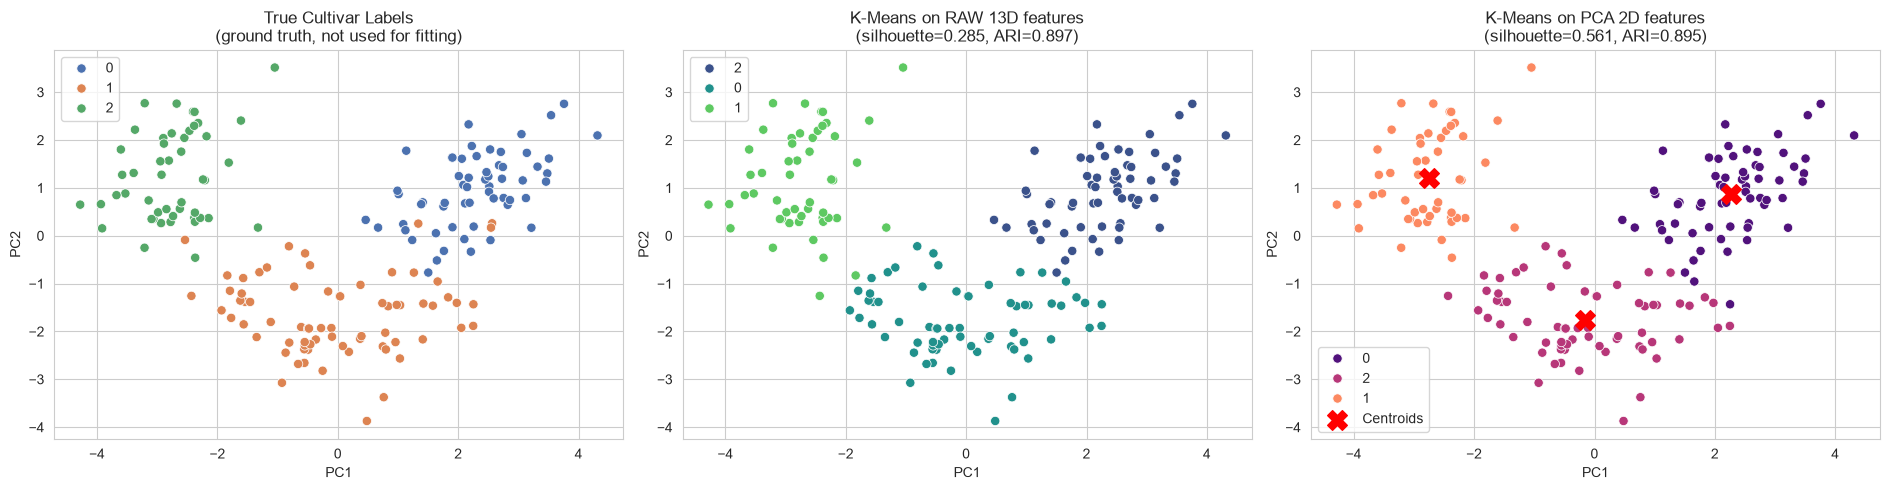

In [8]:
# Visual Comparison: Raw-Feature Clusters vs PCA Clusters


fig, axes = plt.subplots(1, 3, figsize=(19,5))

# Panel 1: True labels (for reference)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_true.astype(str), palette='deep', s=45, ax=axes[0])
axes[0].set_title("True Cultivar Labels\n(ground truth, not used for fitting)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

# Panel 2: K-Means fit on raw 13D features, plotted in PCA space
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_raw.astype(str), palette='viridis', s=45, ax=axes[1])
axes[1].set_title(f"K-Means on RAW 13D features\n(silhouette={sil_raw:.3f}, ARI={ari_raw:.3f})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

# Panel 3: K-Means fit directly on PCA 2D
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_pca.astype(str), palette='magma', s=45, ax=axes[2])
axes[2].scatter(kmeans_pca.cluster_centers_[:,0], kmeans_pca.cluster_centers_[:,1],
                c='red', marker='X', s=200, label='Centroids')
axes[2].set_title(f"K-Means on PCA 2D features\n(silhouette={sil_pca:.3f}, ARI={ari_pca:.3f})")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].legend()

plt.tight_layout()
plt.show()

In [9]:
# Numeric Comparison Table

comparison_df = pd.DataFrame({
    'Approach': ['Raw scaled features (13D)', 'PCA-reduced features (2D)'],
    'Silhouette Score': [sil_raw, sil_pca],
    'Adjusted Rand Index': [ari_raw, ari_pca],
    'Dimensions': [X_scaled.shape[1], X_pca.shape[1]]
})
comparison_df

,Approach,Silhouette Score,Adjusted Rand Index,Dimensions
0,Raw scaled features (13D),0.284859,0.897495,13
1,PCA-reduced features (2D),0.561051,0.895058,2
